In [102]:
import numpy as np
import cv2

In [103]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def visualize_keypoints(img, keypoints, color=(0, 255, 0), radius=4, thickness=2, text_scale=0.5):
    """
    Visualize labeled keypoints on a BGR image.

    Args:
        img (np.ndarray): BGR image.
        keypoints (list): List of [name, x, y].
        color (tuple): BGR color for keypoints & text.
        radius (int): Circle radius for keypoints.
        thickness (int): Circle thickness.
        text_scale (float): Font scale for labels.
    """
    vis = img.copy()

    for name, x, y in keypoints:
        x, y = int(round(x)), int(round(y))
        cv2.circle(vis, (x, y), radius, color, thickness, lineType=cv2.LINE_AA)
        if name.startswith('g_'):
            continue
        cv2.putText(vis, str(name), (x + 5, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, text_scale, color, 2, lineType=cv2.LINE_AA)

    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(20, 20))
    plt.imshow(vis_rgb)
    plt.axis("off")
    plt.title("Keypoint Visualization")
    plt.show()

In [ ]:
XML_STR = """<?xml version="1.0" encoding="utf-8"?>
<annotations>
  <version>1.1</version>
  <meta>
    <task>
      <id>3</id>
      <name>SINGLE</name>
      <size>1</size>
      <mode>annotation</mode>
      <overlap>0</overlap>
      <bugtracker></bugtracker>
      <created>2025-10-24 06:01:35.015071+00:00</created>
      <updated>2025-10-24 06:28:48.322694+00:00</updated>
      <subset>default</subset>
      <start_frame>0</start_frame>
      <stop_frame>0</stop_frame>
      <frame_filter></frame_filter>
      <segments>
        <segment>
          <id>3</id>
          <start>0</start>
          <stop>0</stop>
          <url>http://localhost:8080/api/jobs/3</url>
        </segment>
      </segments>
      <owner>
        <username>dangnh0611</username>
        <email>dangnh0611@gmail.com</email>
      </owner>
      <assignee></assignee>
      <labels>
        <label>
          <name>LEAD</name>
          <color>#66ff66</color>
          <type>polygon</type>
          <attributes>
            <attribute>
              <name>LEAD_NAME</name>
              <mutable>False</mutable>
              <input_type>text</input_type>
              <default_value></default_value>
              <values></values>
            </attribute>
          </attributes>
        </label>
        <label>
          <name>ANCHOR</name>
          <color>#66ff66</color>
          <type>rectangle</type>
          <attributes>
          </attributes>
        </label>
        <label>
          <name>START</name>
          <color>#fa3253</color>
          <type>rectangle</type>
          <attributes>
          </attributes>
        </label>
        <label>
          <name>CELL</name>
          <color>#33ddff</color>
          <type>rectangle</type>
          <attributes>
          </attributes>
        </label>
      </labels>
    </task>
    <dumped>2025-10-24 06:33:15.617123+00:00</dumped>
  </meta>
  <image id="0" name="106482869-0001.png" width="2200" height="1700">
    <box label="CELL" source="manual" occluded="0" xtl="79.41" ytl="716.32" xbr="118.70" ybr="755.60" z_order="0">
    </box>
    <box label="START" source="manual" occluded="0" xtl="79.29" ytl="629.61" xbr="118.69" ybr="708.01" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="607.08" ytl="680.97" xbr="612.80" ybr="736.10" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="1099.21" ytl="680.95" xbr="1104.94" ybr="736.08" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="1591.12" ytl="680.94" xbr="1596.84" ybr="736.07" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="1591.14" ytl="963.88" xbr="1596.86" ybr="1019.01" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="1099.11" ytl="963.94" xbr="1104.83" ybr="1019.07" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="607.19" ytl="963.93" xbr="612.91" ybr="1019.06" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="607.19" ytl="1247.41" xbr="612.91" ybr="1302.54" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="1099.09" ytl="1247.50" xbr="1104.81" ybr="1302.63" z_order="0">
    </box>
    <box label="ANCHOR" source="manual" occluded="0" xtl="1591.13" ytl="1247.50" xbr="1596.86" ybr="1302.63" z_order="0">
    </box>
    <box label="START" source="manual" occluded="0" xtl="79.40" ytl="913.06" xbr="118.80" ybr="991.46" z_order="0">
    </box>
    <box label="START" source="manual" occluded="0" xtl="79.39" ytl="1196.45" xbr="118.79" ybr="1274.85" z_order="0">
    </box>
    <box label="START" source="manual" occluded="0" xtl="79.33" ytl="1456.12" xbr="118.73" ybr="1534.52" z_order="0">
    </box>
  </image>
</annotations>
"""

In [270]:
import xml.etree.ElementTree as ET

def _to_float(s):
    try:
        return float(s)
    except Exception:
        return float(str(s).strip())

def _bbox_from_polygon_points(points_str):
    pts = []
    for p in points_str.strip().strip(';').split(';'):
        if not p:
            continue
        x_str, y_str = p.split(',')
        pts.append((_to_float(x_str), _to_float(y_str)))
    xs = [x for x, _ in pts]
    ys = [y for _, y in pts]
    return min(xs), min(ys), max(xs), max(ys)

def parse_cvat_xml_string(xml_content, round_to_int=False, label_filter=None, sort_boxes=True):
    """
    Parse CVAT XML from a string and return sorted list of (label, x1, y1, x2, y2).

    Sorted by top→bottom (y), then left→right (x).
    """
    root = ET.fromstring(xml_content)
    out = []

    for img in root.findall('.//image'):
        # Rectangles
        for box in img.findall('box'):
            label = box.get('label')
            if label_filter and label not in label_filter:
                continue
            x1 = _to_float(box.get('xtl'))
            y1 = _to_float(box.get('ytl'))
            x2 = _to_float(box.get('xbr'))
            y2 = _to_float(box.get('ybr'))
            if round_to_int:
                x1, y1, x2, y2 = map(lambda v: int(round(v)), (x1, y1, x2, y2))
            out.append((label, x1, y1, x2, y2))

        # Polygons → bounding box
        for poly in img.findall('polygon'):
            label = poly.get('label')
            if label_filter and label not in label_filter:
                continue
            pts = poly.get('points')
            x1, y1, x2, y2 = _bbox_from_polygon_points(pts)
            if round_to_int:
                x1, y1, x2, y2 = map(lambda v: int(round(v)), (x1, y1, x2, y2))
            out.append((label, x1, y1, x2, y2))

    # ---- Sort boxes by top→bottom (y1) then left→right (x1)
    if sort_boxes:
        out.sort(key=lambda b: (b[2], b[1]))  # (y1, x1)

    return out


coords = parse_cvat_xml_string(XML_STR)
coords

[('START', 79.29, 629.61, 118.69, 708.01),
 ('ANCHOR', 1591.12, 680.94, 1596.84, 736.07),
 ('ANCHOR', 1099.21, 680.95, 1104.94, 736.08),
 ('ANCHOR', 607.08, 680.97, 612.8, 736.1),
 ('CELL', 79.41, 716.32, 118.7, 755.6),
 ('START', 79.4, 913.06, 118.8, 991.46),
 ('ANCHOR', 1591.14, 963.88, 1596.86, 1019.01),
 ('ANCHOR', 607.19, 963.93, 612.91, 1019.06),
 ('ANCHOR', 1099.11, 963.94, 1104.83, 1019.07),
 ('START', 79.39, 1196.45, 118.79, 1274.85),
 ('ANCHOR', 607.19, 1247.41, 612.91, 1302.54),
 ('ANCHOR', 1099.09, 1247.5, 1104.81, 1302.63),
 ('ANCHOR', 1591.13, 1247.5, 1596.86, 1302.63),
 ('START', 79.33, 1456.12, 118.73, 1534.52)]

In [271]:
ANCHORS = [
    ('ANCHOR', 607.08, 680.97, 612.8, 736.1),
    ('ANCHOR', 1099.21, 680.95, 1104.94, 736.08),
     ('ANCHOR', 1591.12, 680.94, 1596.84, 736.07),
 
 ('ANCHOR', 607.19, 963.93, 612.91, 1019.06),
 ('ANCHOR', 1099.11, 963.94, 1104.83, 1019.07),
    ('ANCHOR', 1591.14, 963.88, 1596.86, 1019.01),

 ('ANCHOR', 607.19, 1247.41, 612.91, 1302.54),
 ('ANCHOR', 1099.09, 1247.5, 1104.81, 1302.63),
 ('ANCHOR', 1591.13, 1247.5, 1596.86, 1302.63),
]

CALIBS = [
    ('START', 79.29, 629.61, 118.69, 708.01),
    ('START', 79.4, 913.06, 118.8, 991.46),
    ('START', 79.39, 1196.45, 118.79, 1274.85),
    ('START', 79.33, 1456.12, 118.73, 1534.52)
]

In [272]:
anchors = np.array([e[1:] for e in ANCHORS]).reshape(3, 3, -1)
anchors

array([[[ 607.08,  680.97,  612.8 ,  736.1 ],
        [1099.21,  680.95, 1104.94,  736.08],
        [1591.12,  680.94, 1596.84,  736.07]],

       [[ 607.19,  963.93,  612.91, 1019.06],
        [1099.11,  963.94, 1104.83, 1019.07],
        [1591.14,  963.88, 1596.86, 1019.01]],

       [[ 607.19, 1247.41,  612.91, 1302.54],
        [1099.09, 1247.5 , 1104.81, 1302.63],
        [1591.13, 1247.5 , 1596.86, 1302.63]]])

In [273]:
calibs = np.array([e[1:] for e in CALIBS]).reshape(4, -1)
calibs

array([[  79.29,  629.61,  118.69,  708.01],
       [  79.4 ,  913.06,  118.8 ,  991.46],
       [  79.39, 1196.45,  118.79, 1274.85],
       [  79.33, 1456.12,  118.73, 1534.52]])

In [104]:
ref_img = cv2.imread('/home/dangnh36/datasets/ecg/raw/train/106482869/106482869-0001.png')
ref_img.shape, ref_img.dtype

((1700, 2200, 3), dtype('uint8'))

In [275]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_ecg_leads(bgr_image, json_path):
    """
    Display lead bounding boxes + lead name text boxes on a BGR image using matplotlib.
    Only two args: (bgr_image, json_path).
    """
    # Load annotation
    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    def _poly4(box):
        """Accepts dict {'0': [x,y], ...} or list/tuple [[x,y],...x4]; returns (4,2) float32."""
        if isinstance(box, dict):
            pts = [box[str(i)] for i in range(4)]
        else:
            pts = box
        return np.asarray(pts, dtype=np.float32).reshape(4, 2)

    # Convert BGR->RGB for display
    img_rgb = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(24, 20))
    ax.imshow(img_rgb)

    for lead in ann.get("leads", []):
        name = str(lead.get("lead_name", ""))

        # stable-ish RGB color from name
        h = abs(hash(name))
        color = np.array([50 + (h >> 16) % 205, 50 + (h >> 8) % 205, 50 + h % 205]) / 255.0

        # --- Lead bounding box ---
        box = lead.get("lead_bounding_box")
        if box is not None:
            pts = _poly4(box)                         # (x, y)
            xs, ys = pts[:, 0], pts[:, 1]
            # print(xs, ys)
            ax.plot(np.r_[ys, ys[0]], np.r_[xs, xs[0]], color=color, linewidth=1)  # swap -> (row= y, col = x)
            ax.fill(ys, xs, color=color, alpha=0.15)

            # Label near top-left corner (by y then x)
            anchor = pts[np.lexsort((pts[:, 0], pts[:, 1]))[0]]
            ax.text(
                anchor[1] + 5, anchor[0] - 5, name,
                color="white", fontsize=10, weight="bold",
                bbox=dict(facecolor="black", alpha=0.6, pad=1),
            )

        # --- Lead name text bounding box ---
        tbox = lead.get("text_bounding_box")
        if tbox is not None:
            tpts = _poly4(tbox)
            tx, ty = tpts[:, 0], tpts[:, 1]
            ax.plot(
                np.r_[ty, ty[0]], np.r_[tx, tx[0]],
                linestyle="--", linewidth=1.8, color="yellow"
            )

    ax.set_title("ECG Lead & Lead-Name Text Boxes")
    ax.axis("off")
    plt.show()


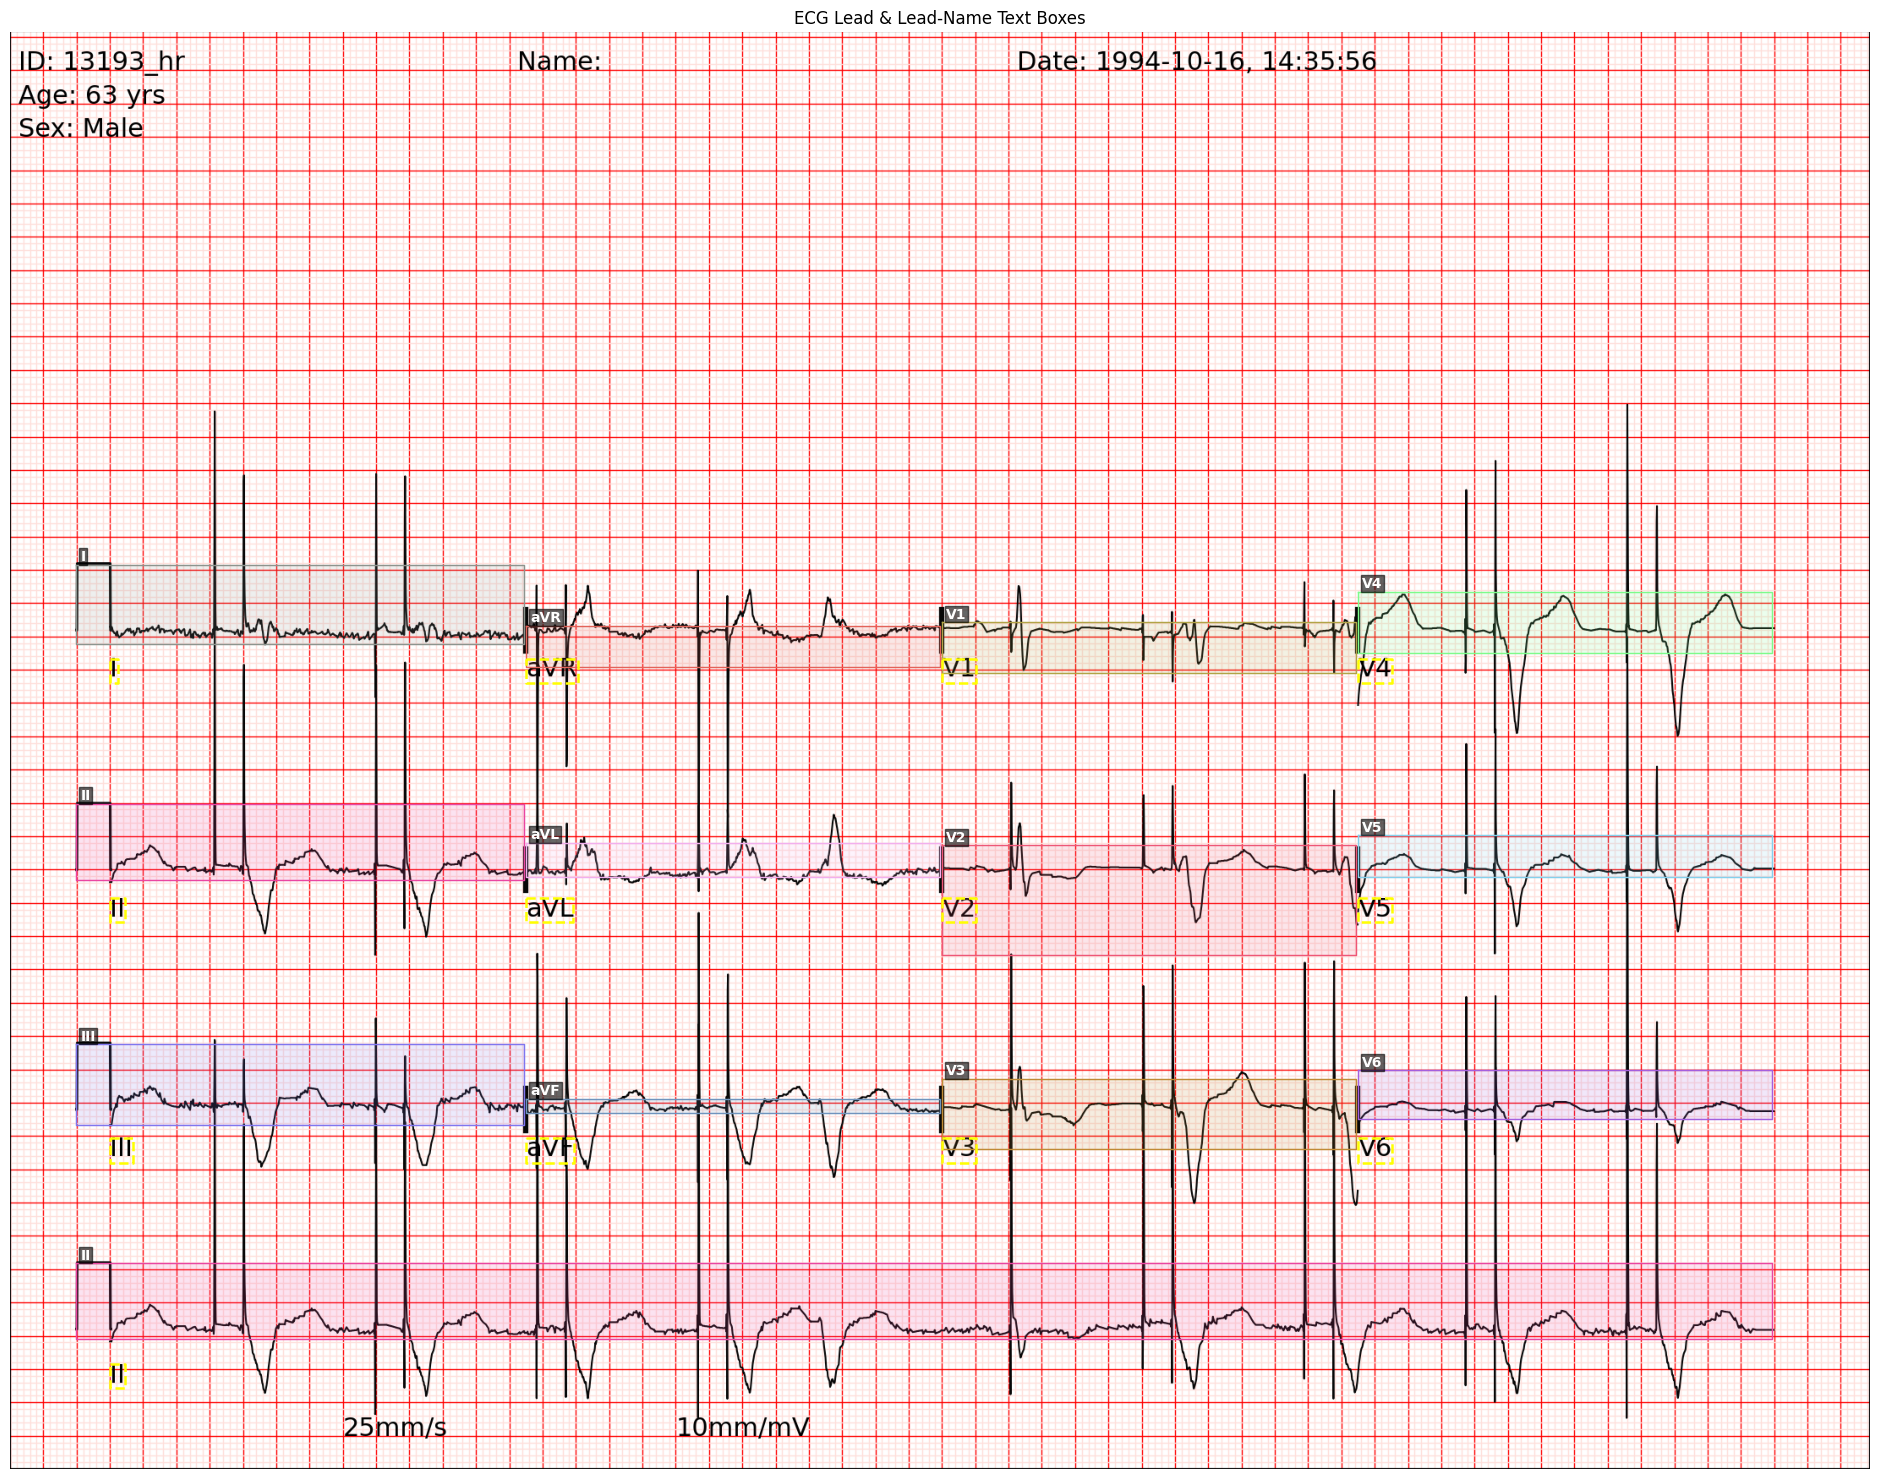

In [276]:
visualize_ecg_leads(ref_img, '../data/00001_lr-0.json')

In [277]:
0.23 / 39.37

0.005842011684023369

In [278]:
import json
import numpy as np

def extract_lead_rects(json_path: str, eps: float = 1.0) -> np.ndarray:
    """
    Read lead polygons (points given as [y, x]) and return (3,4,4) array of [L,T,R,B].
    Handles duplicate lead names by preferring sample_count == 250 (e.g., for lead 'II').

    Grid order (rows x cols):
        Row 0: I, aVR, V1, V4
        Row 1: II, aVL, V2, V5
        Row 2: III, aVF, V3, V6
    """
    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    desired_order = [
        "I", "aVR", "V1", "V4",
        "II", "aVL", "V2", "V5",
        "III", "aVF", "V3", "V6",
    ]

    # Group leads by name (because there can be duplicates like 'II')
    groups = {}
    for lead in ann.get("leads", []):
        name = str(lead.get("lead_name", "")).strip()
        groups.setdefault(name, []).append(lead)

    def _pick_lead(leads_with_same_name):
        """
        Prefer the lead whose (end_sample - start_sample) == 250.
        If multiple match, take the first; otherwise fall back to the first.
        """
        def sample_count(ld):
            s = ld.get("start_sample", 0)
            e = ld.get("end_sample", 0)
            try:
                return int(e) - int(s)
            except Exception:
                return -1

        # exact 250 preference
        preferred = [ld for ld in leads_with_same_name if sample_count(ld) == 250]
        if preferred:
            return preferred[0]
        # fallback: just return the first
        return leads_with_same_name[0]

    def _unique_vals(vals):
        vals = np.sort(np.asarray(vals, dtype=float))
        groups = [vals[0]]
        for v in vals[1:]:
            if abs(v - groups[-1]) > eps:
                groups.append(v)
        return np.array(groups, dtype=float)

    out = np.empty((3, 4, 4), dtype=np.float32)  # [L, T, R, B] per cell

    for idx, lead_name in enumerate(desired_order):
        if lead_name not in groups:
            raise AssertionError(f"Missing lead in JSON: '{lead_name}'")

        lead = _pick_lead(groups[lead_name])
        box = lead.get("lead_bounding_box")
        if box is None:
            raise AssertionError(f"{lead_name}: missing lead_bounding_box")

        # Parse 4 points in (y, x) order from dict {'0': [y,x], ...} or list
        if isinstance(box, dict):
            pts_yx = np.array([box[str(i)] for i in range(4)], dtype=float)
        else:
            pts_yx = np.array(box, dtype=float)

        if pts_yx.shape != (4, 2):
            raise AssertionError(f"{lead_name}: lead_bounding_box must be 4x2, got {pts_yx.shape}")

        ys, xs = pts_yx[:, 0], pts_yx[:, 1]

        # Axis-aligned rectangle check: 2 unique x's and 2 unique y's (within eps)
        ux, uy = _unique_vals(xs), _unique_vals(ys)
        if ux.size != 2 or uy.size != 2:
            raise AssertionError(
                f"{lead_name}: not axis-aligned rectangle (unique x={ux.size}, y={uy.size})."
            )

        L, R = float(np.min(xs)), float(np.max(xs))
        T, B = float(np.min(ys)), float(np.max(ys))

        # Verify each point is near one of the four rectangle corners (in yx space)
        corners_yx = np.array([[T, L], [T, R], [B, L], [B, R]], dtype=float)
        for y, x in pts_yx:
            dists = np.linalg.norm(corners_yx - np.array([y, x]), axis=1)
            if float(np.min(dists)) > eps:
                raise AssertionError(f"{lead_name}: point {(y, x)} not at a rectangle corner within eps={eps}.")

        r, c = divmod(idx, 4)
        out[r, c] = [L, T, R, B]

    return out


```
❯ python3 gen_ecg_images_from_data_batch.py -i SampleData/PTB_XL_data -o output --add_qr_code --mask_unplotted_samples --store_config 2 --lead_name_bbox --lead_bbox --resolution 200
2026-01-07 04:22:26.938376: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-07 04:22:27.055354: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-07 04:22:27.055398: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-07 04:22:27.056479: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 04:22:27.112539: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-07 04:22:27.113109: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-07 04:22:28.316348: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
SAMPLE RATE: 100.0
WIDTH=11 HEIGHT=8.5 RESOLUTION=200
GLOBAL PLOT X/Y MIN/MAX: 0 11.176 0 21.59
LEAD NAME BBOX: III 118.11023622047246 1336.1181102362204 145.11023622047247 1307.1181102362204
DC_PULSE RAW 0.01 III 24 [0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53
 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63] [5.3975 5.3975 6.3975 6.3975 6.3975 6.3975 6.3975 6.3975 6.3975 6.3975
 6.3975 6.3975 6.3975 6.3975 6.3975 6.3975 6.3975 6.3975 6.3975 6.3975
 6.3975 6.3975 5.3975 5.3975]
DC_PULSE 78.74015748031496 425.0 124.01574803149607 503.74015748031496
Y OFFSET: III 5.3975
PRE LEAD X0: III 118.11023622047246
LEAD III 78.74015748031496 407.755905511811 608.2677165354331 503.74015748031496
SEP: III 610.236220472441 1299.800049600099 610.236220472441 1250.199950399901
LEAD NAME BBOX: aVF 610.236220472441 1336.1181102362204 667.361220472441 1307.1181102362204
Y OFFSET: aVF 5.3975
LEAD aVF 610.236220472441 421.85039370078744 1100.3937007874017 438.54330708661416
SEP: aVF 1102.3622047244096 1299.800049600099 1102.3622047244096 1250.199950399901
LEAD NAME BBOX: V3 1102.3622047244096 1336.1181102362204 1142.7372047244096 1307.1181102362204
Y OFFSET: V3 5.3975
LEAD V3 1102.3622047244096 379.40944881889766 1592.5196850393702 462.6377952755905
SEP: V3 1594.4881889763776 1299.800049600099 1594.4881889763776 1250.199950399901
LEAD NAME BBOX: V6 1594.4881889763776 1336.1181102362204 1634.7381889763776 1307.1181102362204
Y OFFSET: V6 5.3975
LEAD V6 1594.4881889763776 414.2125984251969 2084.6456692913384 472.40157480314963
LEAD NAME BBOX: II 118.11023622047246 1052.7847769028872 136.11023622047247 1023.7847769028871
DC_PULSE RAW 0.01 II 24 [0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53
 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63] [8.99583333 8.99583333 9.99583333 9.99583333 9.99583333 9.99583333
 9.99583333 9.99583333 9.99583333 9.99583333 9.99583333 9.99583333
 9.99583333 9.99583333 9.99583333 9.99583333 9.99583333 9.99583333
 9.99583333 9.99583333 9.99583333 9.99583333 8.99583333 8.99583333]
DC_PULSE 78.74015748031496 708.3333333333335 124.01574803149607 787.0734908136484
Y OFFSET: II 8.995833333333334
PRE LEAD X0: II 118.11023622047246
LEAD II 78.74015748031496 697.3097112860893 608.2677165354331 787.0734908136484
SEP: II 610.236220472441 1016.4667162667657 610.236220472441 966.8666170665674
LEAD NAME BBOX: aVL 610.236220472441 1052.7847769028872 666.861220472441 1023.7847769028871
Y OFFSET: aVL 8.995833333333334
LEAD aVL 610.236220472441 701.0892388451443 1100.3937007874017 741.6404199475066
SEP: aVL 1102.3622047244096 1016.4667162667657 1102.3622047244096 966.8666170665674
LEAD NAME BBOX: V2 1102.3622047244096 1052.7847769028872 1142.6122047244096 1023.7847769028871
Y OFFSET: V2 8.995833333333334
LEAD V2 1102.3622047244096 608.727034120735 1592.5196850393702 738.4120734908137
SEP: V2 1594.4881889763776 1016.4667162667657 1594.4881889763776 966.8666170665674
LEAD NAME BBOX: V5 1594.4881889763776 1052.7847769028872 1634.7381889763776 1023.7847769028871
Y OFFSET: V5 8.995833333333334
LEAD V5 1594.4881889763776 701.5616797900262 2084.6456692913384 750.0656167979002
LEAD NAME BBOX: I 118.11023622047246 769.4514435695537 127.11023622047246 740.4514435695537
DC_PULSE RAW 0.01 I 24 [0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53
 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63] [12.59416667 12.59416667 13.59416667 13.59416667 13.59416667 13.59416667
 13.59416667 13.59416667 13.59416667 13.59416667 13.59416667 13.59416667
 13.59416667 13.59416667 13.59416667 13.59416667 13.59416667 13.59416667
 13.59416667 13.59416667 13.59416667 13.59416667 12.59416667 12.59416667]
DC_PULSE 78.74015748031496 991.6666666666665 124.01574803149607 1070.4068241469815
Y OFFSET: I 12.594166666666666
PRE LEAD X0: I 118.11023622047246
LEAD I 78.74015748031496 976.3123359580052 608.2677165354331 1070.4068241469815
SEP: I 610.236220472441 733.1333829334325 610.236220472441 683.5332837332342
LEAD NAME BBOX: aVR 610.236220472441 769.4514435695537 671.111220472441 740.4514435695537
Y OFFSET: aVR 12.594166666666666
LEAD aVR 610.236220472441 949.3044619422571 1100.3937007874017 998.1233595800527
SEP: aVR 1102.3622047244096 733.1333829334325 1102.3622047244096 683.5332837332342
LEAD NAME BBOX: V1 1102.3622047244096 769.4514435695537 1142.6122047244096 740.4514435695537
Y OFFSET: V1 12.594166666666666
LEAD V1 1102.3622047244096 942.6115485564305 1592.5196850393702 1002.8477690288713
SEP: V1 1594.4881889763776 733.1333829334325 1594.4881889763776 683.5332837332342
LEAD NAME BBOX: V4 1594.4881889763776 769.4514435695537 1634.7381889763776 740.4514435695537
Y OFFSET: V4 12.594166666666666
LEAD V4 1594.4881889763776 966.8635170603675 2084.6456692913384 1038.8320209973754
LEAD NAME BBOX: II 118.11023622047246 1603.7034120734909 136.11023622047247 1574.7034120734909
DC_PULSE 78.74015748031496 165.28871391076115 124.01574803149607 244.02887139107605
```

In [279]:
(608 - 78) * 2.5 / 2.7, 1100 - 610, 1592 - 1102

(490.7407407407407, 490, 490)

In [280]:
lead_bboxes = extract_lead_rects('../data/00001_lr-0.json')
lead_bboxes

array([[[  78.,  630.,  608.,  724.],
        [ 610.,  702., 1100.,  751.],
        [1102.,  698., 1592.,  758.],
        [1594.,  662., 2084.,  734.]],

       [[  78.,  913.,  608., 1003.],
        [ 610.,  959., 1100.,  999.],
        [1102.,  962., 1592., 1092.],
        [1594.,  950., 2084.,  999.]],

       [[  78., 1197.,  608., 1293.],
        [ 610., 1262., 1100., 1279.],
        [1102., 1238., 1592., 1321.],
        [1594., 1228., 2084., 1286.]]], dtype=float32)

In [281]:
anchors

array([[[ 607.08,  680.97,  612.8 ,  736.1 ],
        [1099.21,  680.95, 1104.94,  736.08],
        [1591.12,  680.94, 1596.84,  736.07]],

       [[ 607.19,  963.93,  612.91, 1019.06],
        [1099.11,  963.94, 1104.83, 1019.07],
        [1591.14,  963.88, 1596.86, 1019.01]],

       [[ 607.19, 1247.41,  612.91, 1302.54],
        [1099.09, 1247.5 , 1104.81, 1302.63],
        [1591.13, 1247.5 , 1596.86, 1302.63]]])

In [282]:
DC_PULSE = """
DC_PULSE 78.74015748031496 425.0 124.01574803149607 503.74015748031496
DC_PULSE 78.74015748031496 708.3333333333335 124.01574803149607 787.0734908136484
DC_PULSE 78.74015748031496 991.6666666666665 124.01574803149607 1070.4068241469815
"""

In [23]:
2200 / 1.9685039370078812

1117.599999999996

In [24]:
11.176 / (1 / 100)

1117.6

In [22]:
(608.2677165354331 + 610.236220472441) / 2, 610.236220472441 - 608.2677165354331

(609.2519685039371, 1.9685039370078812)

In [283]:
s = """
I 78.74015748031496 976.3123359580052 608.2677165354331 1070.4068241469815
aVR 610.236220472441 949.3044619422571 1100.3937007874017 998.1233595800527
V1 1102.3622047244096 942.6115485564305 1592.5196850393702 1002.8477690288713
V4 1594.4881889763776 966.8635170603675 2084.6456692913384 1038.8320209973754

II 78.74015748031496 697.3097112860893 608.2677165354331 787.0734908136484
aVL 610.236220472441 701.0892388451443 1100.3937007874017 741.6404199475066
V2 1102.3622047244096 608.727034120735 1592.5196850393702 738.4120734908137
V5 1594.4881889763776 701.5616797900262 2084.6456692913384 750.0656167979002

III 78.74015748031496 407.755905511811 608.2677165354331 503.74015748031496
aVF 610.236220472441 421.85039370078744 1100.3937007874017 438.54330708661416
V3 1102.3622047244096 379.40944881889766 1592.5196850393702 462.6377952755905
V6 1594.4881889763776 414.2125984251969 2084.6456692913384 472.40157480314963
"""

lead_bboxes = []
for line in s.splitlines():
    if len(line) < 10:
        continue
    # print(line)
    parts = line.split()
    lead_name = parts[0]
    l, t, r, b = [float(e) for e in parts[1:]]
    lead_bboxes.append([l, t, r, b])
lead_bboxes = np.array(lead_bboxes).reshape(3, 4, -1)
lead_bboxes

array([[[  78.74015748,  976.31233596,  608.26771654, 1070.40682415],
        [ 610.23622047,  949.30446194, 1100.39370079,  998.12335958],
        [1102.36220472,  942.61154856, 1592.51968504, 1002.84776903],
        [1594.48818898,  966.86351706, 2084.64566929, 1038.832021  ]],

       [[  78.74015748,  697.30971129,  608.26771654,  787.07349081],
        [ 610.23622047,  701.08923885, 1100.39370079,  741.64041995],
        [1102.36220472,  608.72703412, 1592.51968504,  738.41207349],
        [1594.48818898,  701.56167979, 2084.64566929,  750.0656168 ]],

       [[  78.74015748,  407.75590551,  608.26771654,  503.74015748],
        [ 610.23622047,  421.8503937 , 1100.39370079,  438.54330709],
        [1102.36220472,  379.40944882, 1592.51968504,  462.63779528],
        [1594.48818898,  414.21259843, 2084.64566929,  472.4015748 ]]])

In [284]:
608.26771654 - 78.74015748, 1100.39370079 - 610.23622047, 1592.51968504 - 1102.36220472, 2084.64566929 - 1594.48818898

(529.52755906, 490.1574803199999, 490.1574803200001, 490.1574803100002)

In [285]:
for i in range(3):
    for j in range(1, 4):
        print((lead_bboxes[i, j-1, 2] + lead_bboxes[i, j, 0]) / 2)

609.2519685039371
1101.3779527559057
1593.503937007874
609.2519685039371
1101.3779527559057
1593.503937007874
609.2519685039371
1101.3779527559057
1593.503937007874


In [286]:
609.2519685039371 - 118.11023622047246, 1101.3779527559057 - 609.2519685039371, 1593.503937007874 - 1101.3779527559057, 1593.503937007874 + 492.12598425196825

(491.1417322834646, 492.1259842519686, 492.12598425196825, 2085.6299212598424)

In [287]:
503.74015748031496 - 425.0, 787.0734908136484 - 708.3333333333335, 1070.4068241469815 - 991.6666666666665

(78.74015748031496, 78.7401574803149, 78.74015748031502)

In [288]:
y = 165.28871391076115
print(1700 - y, 1700 - y - 78.74015748031496)

1534.711286089239 1455.971128608924


In [289]:
708.3333333333335 - 425.0, 991.6666666666665 - 708.3333333333335, 425.0 - 283.3333333333335

(283.3333333333335, 283.33333333333303, 141.66666666666652)

In [290]:
DC_PULSE 78.74015748031496 165.28871391076115 124.01574803149607 244.02887139107605

SyntaxError: invalid syntax (1452410937.py, line 1)

In [291]:
(680.9533333333334 + 736.0833333333334) / 2, (963.9166666666666 + 1019.0466666666667) / 2, (1247.47 + 1302.6000000000001) / 2

(708.5183333333334, 991.4816666666667, 1275.035)

In [292]:
1101.3779527559057 - 609.251968505, 1593.503937007874 - 1101.3779527559057, 609.251968505 - 124.01574803149607

(492.1259842509056, 492.12598425196825, 485.236220473504)

In [293]:
141.66666666666652 / 39.37

3.5983405300143896

In [294]:
(1534.711286089239 + 1275.0) / 2

1404.8556430446195

In [295]:
708.3333333333335 - 141.66666666666652

566.666666666667

In [296]:
991.6666666666665 - 708.3333333333335, 1275.0 - 991.6666666666665, 1534.711286089239 - 1275.0

(283.33333333333303, 283.3333333333335, 259.7112860892389)

In [297]:
283.33333333333303 / 39.37, 259.7112860892389 / 39.37

(7.196681060028779, 6.596679860026389)

In [298]:
1700 - 400.1999503999008

1299.800049600099

In [299]:
1299.800049600099 - 1250.199950399901

49.6000992001982

In [300]:
49.6000992001982 / 39.37

1.259845039375113

In [301]:
2 / 11.176 * 2200,  4 / 11.176 * 2200, 1700 - 0.5 / 21.59 * 1700

(393.7007874015748, 787.4015748031496, 1660.6299212598426)

In [302]:
8.5 * 200, 11 * 200

(1700.0, 2200)

In [303]:
SEP: III 610.236220472441 1299.800049600099 610.236220472441 1250.199950399901
SEP: aVF 1102.3622047244096 1299.800049600099 1102.3622047244096 1250.199950399901
SEP: V3 1594.4881889763776 1299.800049600099 1594.4881889763776 1250.199950399901

SEP: II 610.236220472441 1016.4667162667657 610.236220472441 966.8666170665674
SEP: aVL 1102.3622047244096 1016.4667162667657 1102.3622047244096 966.8666170665674
SEP: V2 1594.4881889763776 1016.4667162667657 1594.4881889763776 966.8666170665674

SEP: I 610.236220472441 733.1333829334325 610.236220472441 683.5332837332342
SEP: aVR 1102.3622047244096 733.1333829334325 1102.3622047244096 683.5332837332342
SEP: V1 1594.4881889763776 733.1333829334325 1594.4881889763776 683.5332837332342



GLOBAL PLOT X/Y MIN/MAX 0 11.176 0 21.59

Y OFFSET: III 5.3975 -> 32.385064770129546 * 39.37
Y OFFSET: II 8.995833333333334 -> 25.18838371010075 * 39.37
Y OFFSET: I 12.594166666666666 -> 17.991702650071964




LEAD NAME BBOX: III 118.11023622047246 1336.1181102362204 145.11023622047247 1307.1181102362204
LEAD NAME BBOX: aVF 610.236220472441 1336.1181102362204 667.361220472441 1307.1181102362204
LEAD NAME BBOX: V3 1102.3622047244096 1336.1181102362204 1142.7372047244096 1307.1181102362204
LEAD NAME BBOX: V6 1594.4881889763776 1336.1181102362204 1634.7381889763776 1307.1181102362204
LEAD NAME BBOX: II 118.11023622047246 1052.7847769028872 136.11023622047247 1023.7847769028871
LEAD NAME BBOX: aVL 610.236220472441 1052.7847769028872 666.861220472441 1023.7847769028871
LEAD NAME BBOX: V2 1102.3622047244096 1052.7847769028872 1142.6122047244096 1023.7847769028871
LEAD NAME BBOX: V5 1594.4881889763776 1052.7847769028872 1634.7381889763776 1023.7847769028871
LEAD NAME BBOX: I 118.11023622047246 769.4514435695537 127.11023622047246 740.4514435695537
LEAD NAME BBOX: aVR 610.236220472441 769.4514435695537 671.111220472441 740.4514435695537
LEAD NAME BBOX: V1 1102.3622047244096 769.4514435695537 1142.6122047244096 740.4514435695537
LEAD NAME BBOX: V4 1594.4881889763776 769.4514435695537 1634.7381889763776 740.4514435695537
LEAD NAME BBOX: II 118.11023622047246 1603.7034120734909 136.11023622047247 1574.7034120734909

SyntaxError: invalid syntax (2693844097.py, line 1)

In [304]:
s = """
LEAD NAME BBOX: III 118.11023622047246 1336.1181102362204 145.11023622047247 1307.1181102362204
LEAD NAME BBOX: aVF 610.236220472441 1336.1181102362204 667.361220472441 1307.1181102362204
LEAD NAME BBOX: V3 1102.3622047244096 1336.1181102362204 1142.7372047244096 1307.1181102362204
LEAD NAME BBOX: V6 1594.4881889763776 1336.1181102362204 1634.7381889763776 1307.1181102362204
LEAD NAME BBOX: II 118.11023622047246 1052.7847769028872 136.11023622047247 1023.7847769028871
LEAD NAME BBOX: aVL 610.236220472441 1052.7847769028872 666.861220472441 1023.7847769028871
LEAD NAME BBOX: V2 1102.3622047244096 1052.7847769028872 1142.6122047244096 1023.7847769028871
LEAD NAME BBOX: V5 1594.4881889763776 1052.7847769028872 1634.7381889763776 1023.7847769028871
LEAD NAME BBOX: I 118.11023622047246 769.4514435695537 127.11023622047246 740.4514435695537
LEAD NAME BBOX: aVR 610.236220472441 769.4514435695537 671.111220472441 740.4514435695537
LEAD NAME BBOX: V1 1102.3622047244096 769.4514435695537 1142.6122047244096 740.4514435695537
LEAD NAME BBOX: V4 1594.4881889763776 769.4514435695537 1634.7381889763776 740.4514435695537
LEAD NAME BBOX: II_full 118.11023622047246 1603.7034120734909 136.11023622047247 1574.7034120734909
"""

kpts = []
for line in s.splitlines():
    if len(line) < 10:
        continue
    # print(line)
    parts = line.split()[3:]
    lead_name = parts[0]
    l, t, r, b = [float(e) for e in parts[1:]]
    # kpts.append([f'ln_{lead_name}', (l + r) / 2, (t + b) / 2])
    kpts.append([f'n_{lead_name}', l, t])
kpts

[['n_III', 118.11023622047246, 1336.1181102362204],
 ['n_aVF', 610.236220472441, 1336.1181102362204],
 ['n_V3', 1102.3622047244096, 1336.1181102362204],
 ['n_V6', 1594.4881889763776, 1336.1181102362204],
 ['n_II', 118.11023622047246, 1052.7847769028872],
 ['n_aVL', 610.236220472441, 1052.7847769028872],
 ['n_V2', 1102.3622047244096, 1052.7847769028872],
 ['n_V5', 1594.4881889763776, 1052.7847769028872],
 ['n_I', 118.11023622047246, 769.4514435695537],
 ['n_aVR', 610.236220472441, 769.4514435695537],
 ['n_V1', 1102.3622047244096, 769.4514435695537],
 ['n_V4', 1594.4881889763776, 769.4514435695537],
 ['n_II_full', 118.11023622047246, 1603.7034120734909]]

In [305]:
1700 * (1 - 8.995833333333334 / 21.59)

991.6666666666665

In [306]:
(733.1333829334325 - 683.5332837332342 +  1016.4667162667657 - 966.8666170665674 +  1299.800049600099 - 1250.199950399901) / 3

49.60009920019828

In [307]:
1534.711286089239 + 49.60009920019828 / 2

1559.511335689338

In [53]:
1700 - 425

1275

In [374]:
DC_PULSE = """
DC_PULSE 78.74015748031496 425.0 124.01574803149607 503.74015748031496
DC_PULSE 78.74015748031496 708.3333333333335 124.01574803149607 787.0734908136484
DC_PULSE 78.74015748031496 991.6666666666665 124.01574803149607 1070.4068241469815
"""

FINAL_KEYPOINTS = [
 # SPLIT (TICK)
 ['s_0_0_t', 609.251968505, 683.5332837332342],
 ['s_0_0_b', 609.251968505, 733.1333829334325],
 ['s_0_1_t',1101.3779527559057, 683.5332837332342],
 ['s_0_1_b',1101.3779527559057, 733.1333829334325],
 ['s_0_2_t',1593.503937007874, 683.5332837332342],
 ['s_0_2_b',1593.503937007874, 733.1333829334325],
    
 ['s_0_3_t',2084.6456692913384, 683.5332837332342],
 ['s_0_3_b',2084.6456692913384, 733.1333829334325],
 
 ['s_1_0_t', 609.2519685039371 , 966.8666170665674],
 ['s_1_0_b', 609.2519685039371 , 1016.4667162667657],
 ['s_1_1_t', 1101.3779527559057  , 966.8666170665674],
 ['s_1_1_b', 1101.3779527559057 , 1016.4667162667657],
 ['s_1_2_t', 1593.503937007874 , 966.8666170665674],
 ['s_1_2_b', 1593.503937007874 , 1016.4667162667657],

 ['s_1_3_t',2084.6456692913384, 966.8666170665674 ],
 ['s_1_3_b',2084.6456692913384, 1016.4667162667657],
    
 ['s_2_0_t', 609.2519685039371 , 1250.199950399901],
 ['s_2_0_b', 609.2519685039371 , 1299.800049600099],
 ['s_2_1_t',1101.3779527559057 , 1250.199950399901],
 ['s_2_1_b',1101.3779527559057 , 1299.800049600099],
 ['s_2_2_t', 1593.503937007874 , 1250.199950399901],
 ['s_2_2_b', 1593.503937007874 , 1299.800049600099],

 ['s_2_3_t',2084.6456692913384, 1250.199950399901],
 ['s_2_3_b',2084.6456692913384, 1299.800049600099],

 ['s_3_3_t',2084.6456692913384, 1509.9112364891398],
 ['s_3_3_b',2084.6456692913384, 1559.511335689338],

 # DC PULSE
 # 124.01574803149607
 ['dc_0_0', 78.74015748, 629.5931758530185],
 ['dc_0_1', 118.11023622047246, 629.5931758530185],
 ['dc_0_2', 118.11023622047246, 708.3333333333335],
 ['dc_0_3', 78.74015748, 708.3333333333335],

 ['dc_1_0', 78.74015748, 912.9265091863515],
 ['dc_1_1', 118.11023622047246, 912.9265091863515],
 ['dc_1_2', 118.11023622047246, 991.6666666666665],
 ['dc_1_3', 78.74015748, 991.6666666666665],

 ['dc_2_0', 78.74015748, 1196.259842519685],
 ['dc_2_1', 118.11023622047246 , 1196.259842519685],
 ['dc_2_2', 118.11023622047246, 1275.0],
 ['dc_2_3', 78.74015748, 1275.0],

 ['dc_3_0', 78.74015748, 1455.971128608924],
 ['dc_3_1', 118.11023622047246, 1455.971128608924],
 ['dc_3_2', 118.11023622047246, 1534.711286089239],
 ['dc_3_3', 78.74015748, 1534.711286089239],

    
 # LEAD NAMES
 ['n_III', 131.61023622047247, 1321.6181102362204],
 ['n_aVF', 638.798720472441, 1321.6181102362204],
 ['n_V3', 1122.5497047244096, 1321.6181102362204],
 ['n_V6', 1614.6131889763776, 1321.6181102362204],
 ['n_II', 127.11023622047247, 1038.2847769028872],
 ['n_aVL', 638.548720472441, 1038.2847769028872],
 ['n_V2', 1122.4872047244096, 1038.2847769028872],
 ['n_V5', 1614.6131889763776, 1038.2847769028872],
 ['n_I', 122.61023622047246, 754.9514435695537],
 ['n_aVR', 640.673720472441, 754.9514435695537],
 ['n_V1', 1122.4872047244096, 754.9514435695537],
 ['n_V4', 1614.6131889763776, 754.9514435695537],
 ['n_II_full', 127.11023622047247, 1589.2034120734909],


 # TEXT
 # (393.7007874015748, 787.4015748031496, 1660.6299212598426)
 ['mms', 393.7007874015748, 1660.6299212598426],
 ['mmmv', 787.4015748031496, 1660.6299212598426],

 # CORNERS
 # ['c_0_0', 118.11023622047246, 566.666666666667 ],
 # ['c_0_1', 609.251968505, 566.666666666667 ],
 # ['c_0_2', 1101.3779527559057, 566.666666666667 ],
 # ['c_0_3', 1593.503937007874, 566.666666666667 ],
 # ['c_0_4', 2084.64566929, 566.666666666667],
    
 # ['c_1_0', 118.11023622047246, 850.0],
 # ['c_1_1', 609.251968505, 850.0],
 # ['c_1_2', 1101.3779527559057, 850.0],
 # ['c_1_3', 1593.503937007874, 850.0],
 # ['c_1_4', 2084.64566929, 850.0],

 # ['c_2_0', 118.11023622047246, 1133.3333333333333],
 # ['c_2_1', 609.251968505, 1133.3333333333333],
 # ['c_2_2', 1101.3779527559057, 1133.3333333333333],
 # ['c_2_3', 1593.503937007874, 1133.3333333333333],
 # ['c_2_4', 2084.64566929, 1133.3333333333333],

 # ['c_3_0', 118.11023622047246, 1404.8556430446195],
 # ['c_3_1', 609.251968505, 1404.8556430446195],
 # ['c_3_2', 1101.3779527559057, 1404.8556430446195],
 # ['c_3_3', 1593.503937007874, 1404.8556430446195],
 # ['c_3_4', 2084.64566929, 1404.8556430446195],

 # ['c_4_0', 118.11023622047246, ],
 # ['c_4_1', 609.251968505, ],
 # ['c_4_2', 1101.3779527559057, ],
 # ['c_4_3', 1593.503937007874, ],
 # ['c_4_4', 2084.64566929, ],
]

In [375]:
21.59 * 2, 11.176 * 5

(43.18, 55.88)

In [376]:
8.5 * 200 / 43.18, 11 * 200 / 55.88

(39.37007874015748, 39.37007874015748)

In [377]:
1

1

In [378]:
grid_xys = []
for i in range(43):
    for j in range(1, 56):
        y = 1700 - (39.37007874015748 * (43 - i))
        x = 39.37007874015748 * j
        grid_xys.append([f'g_{i}_{j}', x, y])
# grid_xys = grid_xys[::-1]
print(len(grid_xys))
print(grid_xys[:10])
print(grid_xys[-10:])

2365
[['g_0_1', 39.37007874015748, 7.086614173228327], ['g_0_2', 78.74015748031496, 7.086614173228327], ['g_0_3', 118.11023622047244, 7.086614173228327], ['g_0_4', 157.48031496062993, 7.086614173228327], ['g_0_5', 196.8503937007874, 7.086614173228327], ['g_0_6', 236.2204724409449, 7.086614173228327], ['g_0_7', 275.59055118110234, 7.086614173228327], ['g_0_8', 314.96062992125985, 7.086614173228327], ['g_0_9', 354.33070866141736, 7.086614173228327], ['g_0_10', 393.7007874015748, 7.086614173228327]]
[['g_42_46', 1811.023622047244, 1660.6299212598426], ['g_42_47', 1850.3937007874017, 1660.6299212598426], ['g_42_48', 1889.763779527559, 1660.6299212598426], ['g_42_49', 1929.1338582677165, 1660.6299212598426], ['g_42_50', 1968.5039370078741, 1660.6299212598426], ['g_42_51', 2007.8740157480315, 1660.6299212598426], ['g_42_52', 2047.2440944881891, 1660.6299212598426], ['g_42_53', 2086.6141732283463, 1660.6299212598426], ['g_42_54', 2125.984251968504, 1660.6299212598426], ['g_42_55', 2165.354330

In [379]:
FINAL_KEYPOINTS = grid_xys + FINAL_KEYPOINTS

In [380]:
FINAL_KEYPOINTS_DICT = {e[0]: e[1:] for e in FINAL_KEYPOINTS}
FINAL_KEYPOINTS_DICT

{'g_0_1': [39.37007874015748, 7.086614173228327],
 'g_0_2': [78.74015748031496, 7.086614173228327],
 'g_0_3': [118.11023622047244, 7.086614173228327],
 'g_0_4': [157.48031496062993, 7.086614173228327],
 'g_0_5': [196.8503937007874, 7.086614173228327],
 'g_0_6': [236.2204724409449, 7.086614173228327],
 'g_0_7': [275.59055118110234, 7.086614173228327],
 'g_0_8': [314.96062992125985, 7.086614173228327],
 'g_0_9': [354.33070866141736, 7.086614173228327],
 'g_0_10': [393.7007874015748, 7.086614173228327],
 'g_0_11': [433.07086614173227, 7.086614173228327],
 'g_0_12': [472.4409448818898, 7.086614173228327],
 'g_0_13': [511.8110236220473, 7.086614173228327],
 'g_0_14': [551.1811023622047, 7.086614173228327],
 'g_0_15': [590.5511811023622, 7.086614173228327],
 'g_0_16': [629.9212598425197, 7.086614173228327],
 'g_0_17': [669.2913385826772, 7.086614173228327],
 'g_0_18': [708.6614173228347, 7.086614173228327],
 'g_0_19': [748.0314960629921, 7.086614173228327],
 'g_0_20': [787.4015748031496, 7.0

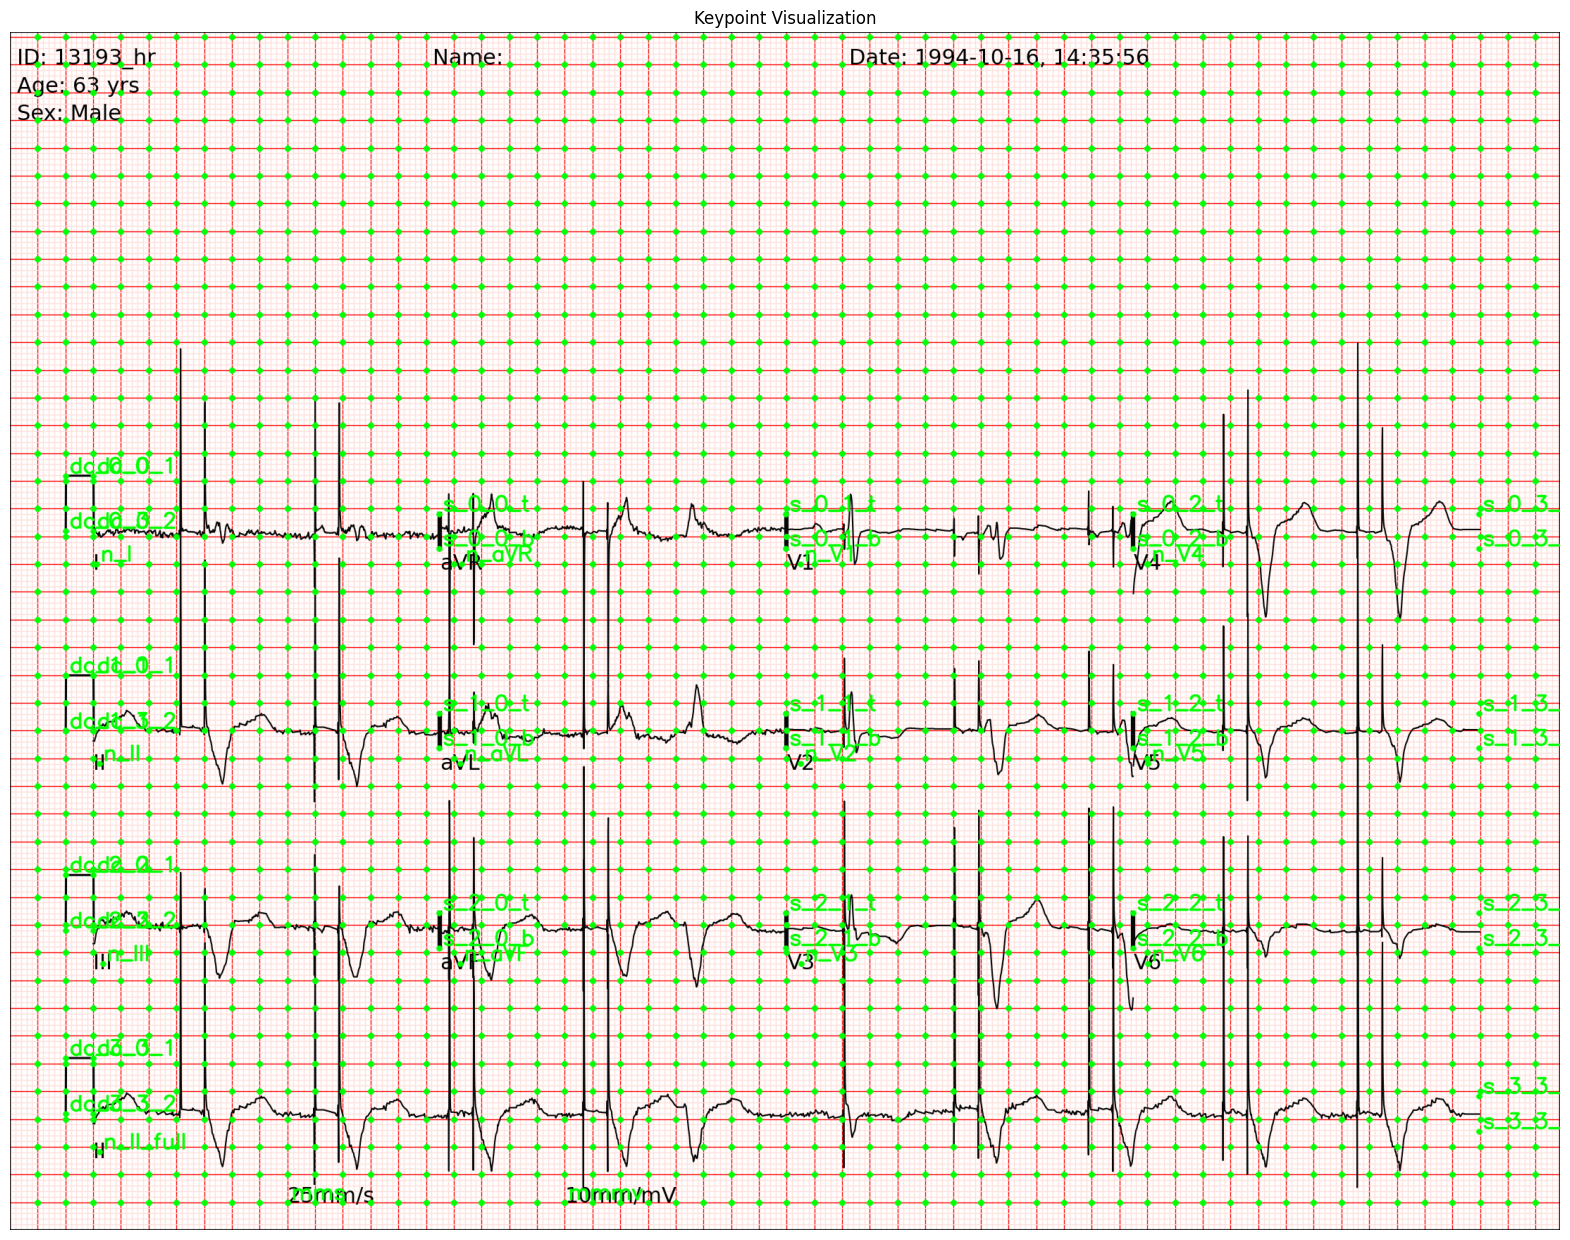

In [381]:
visualize_keypoints(ref_img, FINAL_KEYPOINTS + grid_xys, color=(0, 255, 0), radius=2, thickness=3, text_scale=1)
# keypoints

In [382]:
len(FINAL_KEYPOINTS_DICT)

2422

In [383]:
with open('/home/dangnh36/datasets/ecg/processed/reference_keypoints.json', 'w') as f:
    json.dump(FINAL_KEYPOINTS_DICT, f)

In [384]:
!cat /home/dangnh36/datasets/ecg/processed/reference_keypoints.json

{"g_0_1": [39.37007874015748, 7.086614173228327], "g_0_2": [78.74015748031496, 7.086614173228327], "g_0_3": [118.11023622047244, 7.086614173228327], "g_0_4": [157.48031496062993, 7.086614173228327], "g_0_5": [196.8503937007874, 7.086614173228327], "g_0_6": [236.2204724409449, 7.086614173228327], "g_0_7": [275.59055118110234, 7.086614173228327], "g_0_8": [314.96062992125985, 7.086614173228327], "g_0_9": [354.33070866141736, 7.086614173228327], "g_0_10": [393.7007874015748, 7.086614173228327], "g_0_11": [433.07086614173227, 7.086614173228327], "g_0_12": [472.4409448818898, 7.086614173228327], "g_0_13": [511.8110236220473, 7.086614173228327], "g_0_14": [551.1811023622047, 7.086614173228327], "g_0_15": [590.5511811023622, 7.086614173228327], "g_0_16": [629.9212598425197, 7.086614173228327], "g_0_17": [669.2913385826772, 7.086614173228327], "g_0_18": [708.6614173228347, 7.086614173228327], "g_0_19": [748.0314960629921, 7.086614173228327], "g_0_20": [787.4015748031496, 7.086614173228327], "g

## Determine standard LEAD bbox center

In [117]:
import json
import numpy as np

with open(
    "/home/dangnh36/datasets/ecg/processed/reference_keypoints.json", "r"
) as f:
    ref_kpts = json.load(f)
ref_kpt_xys = np.array(list(ref_kpts.values()))
ref_kpt_names = list(ref_kpts.keys())
len(ref_kpt_names), ref_kpt_xys.shape

(2422, (2422, 2))

In [119]:
ref_kpt_names.index('dc_0_0'), ref_kpt_names.index('s_0_2_t'), ref_kpt_names.index('s_2_2_b'), ref_kpt_names.index('dc_3_3')

(2391, 2369, 2386, 2406)

In [45]:
# y=0 line == center_y of TICK == bottom corner of DC PULSE
(683.5332837332342 + 733.1333829334325) / 2, (966.8666170665674 + 1016.4667162667657) / 2, (1250.199950399901 + 1299.800049600099) / 2, (1509.9112364891398 + 1559.511335689338) / 2

(708.3333333333333, 991.6666666666665, 1275.0, 1534.711286089239)

In [50]:
(609.251968505 - 118.11023622047246) * 250 / 249.5, 1101.3779527559057 - 609.251968505, 1593.503937007874 - 1101.3779527559057, (2084.6456692913384 - 1593.503937007874) * (250 / 249.5), (2084.6456692913384 - 118.11023622047246) * 250 / 999 

(492.1259842530336,
 492.1259842509056,
 492.12598425196825,
 492.1259842519684,
 492.1259842519685)

In [61]:
(609.251968505 - 118.11023622047246) * 249 / 249.5

490.1574803160215

In [79]:
2200 / 11.176 * (1 / 100), 1.968503937007874 * (100 * 2.5)

(1.968503937007874, 492.12598425196853)

In [80]:
2200 / 11.176 * (1 / 512), 0.3844734251968504 * (512 * 2.5)

(0.3844734251968504, 492.12598425196853)

In [74]:
1.968503937007874 * 249

490.15748031496065

In [69]:
249 / 2

124.5

In [82]:
118.11023622047246 + 1.968503937007874 * 249 / 2, 118.11023622047246 + 0.3844734251968504 * (512 * 2.5 - 1) / 2

(363.18897637795277, 363.9809916338583)

In [83]:
1.968503937007874 * 250

492.12598425196853

In [90]:
512 * 2.5 - 1

1279.0

In [89]:
STEP = 2200 / 11.176 * (1 / 512)
STEP

0.3844734251968504

In [96]:
2084.6456692913384 - 2086.6141732283468

-1.968503937008336

In [97]:
118.11023622047246 + STEP * 512 * 2.5 * 3, 118.11023622047246 + 1.968503937007874 * 100 * 2.5

(1594.488188976378, 610.236220472441)

In [99]:
(1593.503937007874 - 1594.488188976378) * 2

-1.968503937008336

In [112]:
1.968503937007874 * 250

492.12598425196853

In [105]:
# step for sampling_rate=100: 1.968503937007874
# step for sampling_rate=512: 0.3844734251968504

LEAD_LEFT_MID_KEYPOINTS = {
    'I': [118.11023622047246, 708.3333333333335],
    'aVR': [610.236220472441, 708.3333333333335],
    'V1': [1102.3622047244096, 708.3333333333335],
    'V4': [1594.488188976378, 708.3333333333335],

    'II_short': [118.11023622047246, 991.6666666666665],
    'aVL': [610.236220472441, 991.6666666666665],
    'V2': [1102.3622047244096, 991.6666666666665],
    'V5': [1594.488188976378, 991.6666666666665],

    'III': [118.11023622047246, 1275.0],
    'aVF': [610.236220472441, 1275.0],
    'V3': [1102.3622047244096, 1275.0],
    'V6': [1594.488188976378, 1275.0],

    'II_long': [118.11023622047246, 1534.711286089239]
}

LEAD_LEFT_MID_KEYPOINTS

{'I': [118.11023622047246, 708.3333333333335],
 'aVR': [610.236220472441, 708.3333333333335],
 'V1': [1102.3622047244096, 708.3333333333335],
 'V4': [1594.488188976378, 708.3333333333335],
 'II_short': [118.11023622047246, 991.6666666666665],
 'aVL': [610.236220472441, 991.6666666666665],
 'V2': [1102.3622047244096, 991.6666666666665],
 'V5': [1594.488188976378, 991.6666666666665],
 'III': [118.11023622047246, 1275.0],
 'aVF': [610.236220472441, 1275.0],
 'V3': [1102.3622047244096, 1275.0],
 'V6': [1594.488188976378, 1275.0],
 'II_long': [118.11023622047246, 1534.711286089239]}

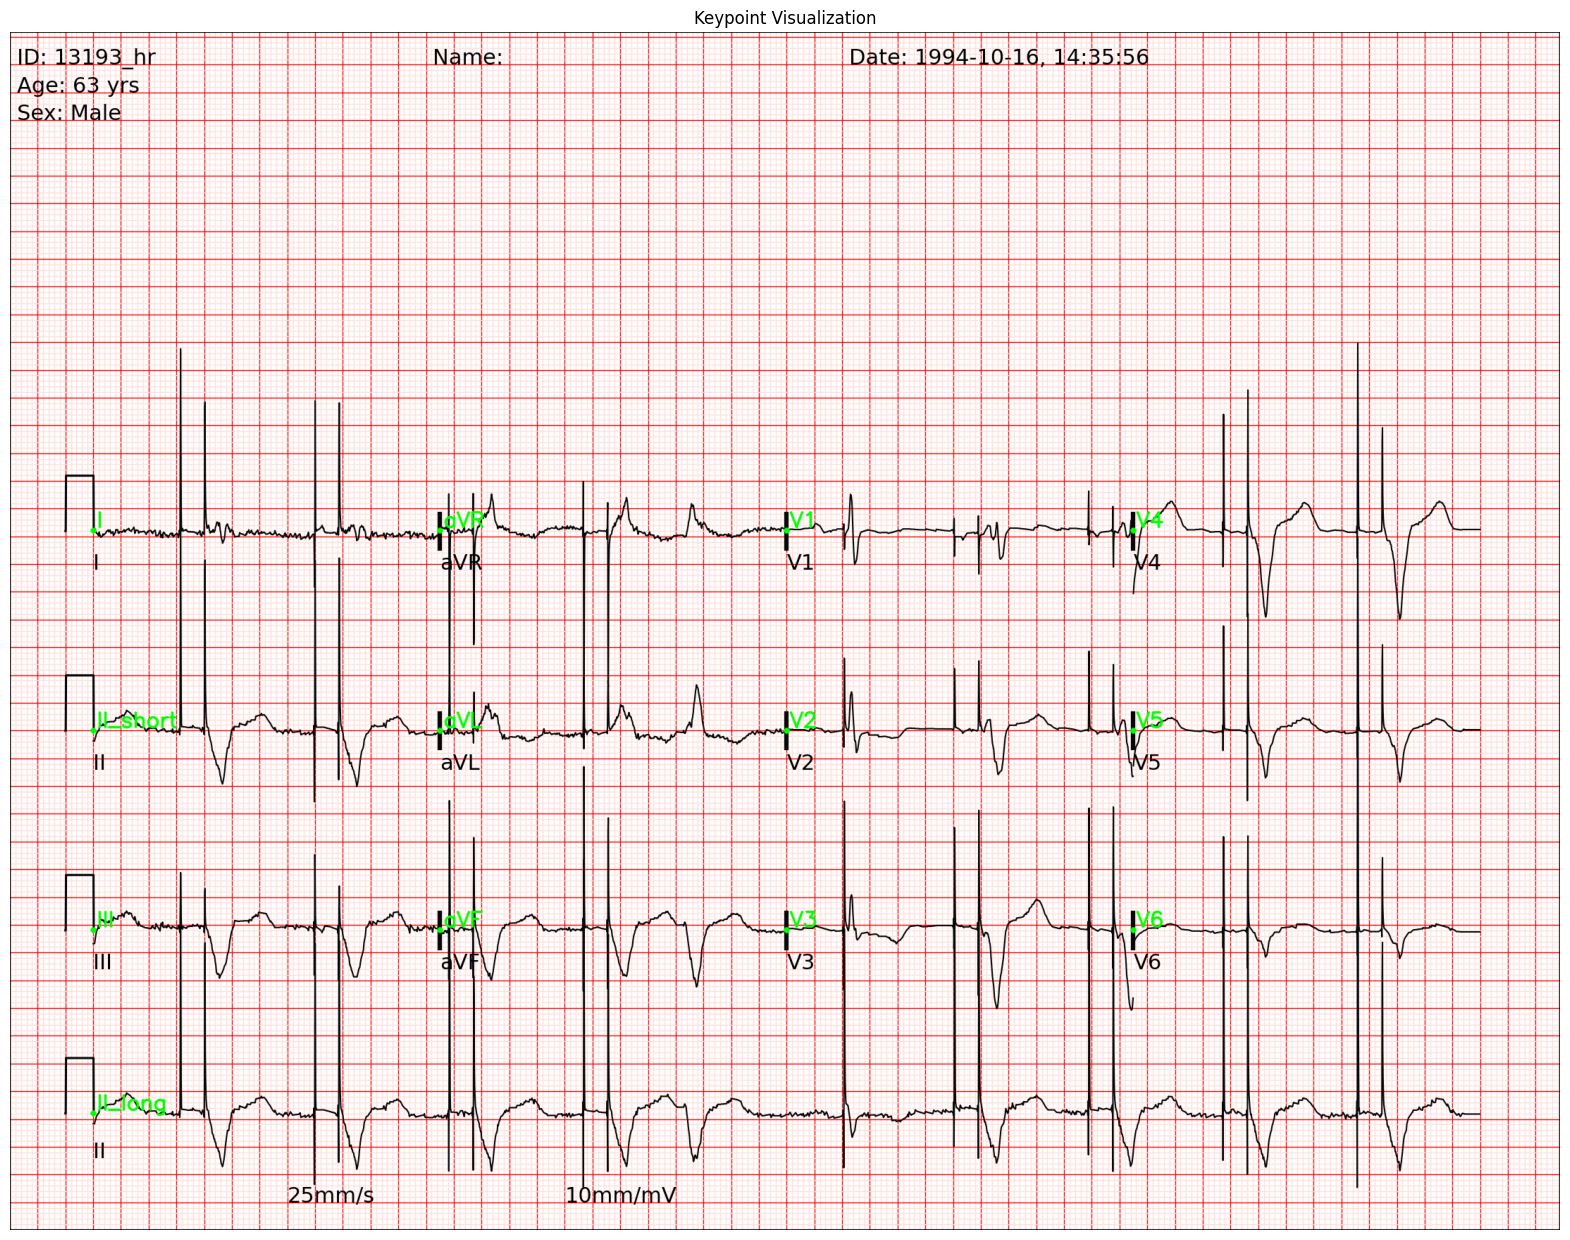

In [110]:
# xy + [0.5, -0.5] due to offset bug
# int(x) or round(x - 0.5) to convert from contigous coordinate space to pixel indices space
visualize_keypoints(ref_img, [(name, int(x + 0.5), int(y - 0.5)) for name, (x, y) in LEAD_LEFT_MID_KEYPOINTS.items()], color=(0, 255, 0), radius=2, thickness=3, text_scale=1)

In [36]:
# LEAD V4 1594.4881889763776 966.8635170603675 2084.6456692913384 1038.8320209973754
2200 / ((2084.6456692913384 - 1594.4881889763776) / 249)

1117.5999999999997

In [38]:
(609.251968505 - 118.11023622047246) * 250 / 249.5, 1101.3779527559057 - 609.251968505, 1593.503937007874 - 1101.3779527559057, (2084.6456692913384 - 1593.503937007874) * (250 / 249.5), (2084.6456692913384 - 118.11023622047246) * 250 / 999 

(492.1259842530336,
 492.1259842509056,
 492.12598425196825,
 492.1259842519684,
 492.1259842519685)

In [55]:
(609.251968505 - 118.11023622047246) * 249 / 249.5

490.1574803160215

In [41]:
(118.11023622047246 - 78.74015748) * 250 / 20

492.1259842559058

In [27]:
2200 / (492.1259842509056 / 250)

1117.600000002414

In [6]:
FINAL_KEYPOINTS = [
 # SPLIT (TICK)
 ['s_0_0_t', 609.251968505, 683.5332837332342],
 ['s_0_0_b', 609.251968505, 733.1333829334325],
 ['s_0_1_t',1101.3779527559057, 683.5332837332342],
 ['s_0_1_b',1101.3779527559057, 733.1333829334325],
 ['s_0_2_t',1593.503937007874, 683.5332837332342],
 ['s_0_2_b',1593.503937007874, 733.1333829334325],
    
 ['s_0_3_t',2084.6456692913384, 683.5332837332342],
 ['s_0_3_b',2084.6456692913384, 733.1333829334325],
 
 ['s_1_0_t', 609.2519685039371 , 966.8666170665674],
 ['s_1_0_b', 609.2519685039371 , 1016.4667162667657],
 ['s_1_1_t', 1101.3779527559057  , 966.8666170665674],
 ['s_1_1_b', 1101.3779527559057 , 1016.4667162667657],
 ['s_1_2_t', 1593.503937007874 , 966.8666170665674],
 ['s_1_2_b', 1593.503937007874 , 1016.4667162667657],

 ['s_1_3_t',2084.6456692913384, 966.8666170665674 ],
 ['s_1_3_b',2084.6456692913384, 1016.4667162667657],
    
 ['s_2_0_t', 609.2519685039371 , 1250.199950399901],
 ['s_2_0_b', 609.2519685039371 , 1299.800049600099],
 ['s_2_1_t',1101.3779527559057 , 1250.199950399901],
 ['s_2_1_b',1101.3779527559057 , 1299.800049600099],
 ['s_2_2_t', 1593.503937007874 , 1250.199950399901],
 ['s_2_2_b', 1593.503937007874 , 1299.800049600099],

 ['s_2_3_t',2084.6456692913384, 1250.199950399901],
 ['s_2_3_b',2084.6456692913384, 1299.800049600099],

 ['s_3_3_t',2084.6456692913384, 1509.9112364891398],
 ['s_3_3_b',2084.6456692913384, 1559.511335689338],

 # DC PULSE
 # 124.01574803149607
 ['dc_0_0', 78.74015748, 629.5931758530185],
 ['dc_0_1', 118.11023622047246, 629.5931758530185],
 ['dc_0_2', 118.11023622047246, 708.3333333333335],
 ['dc_0_3', 78.74015748, 708.3333333333335],

 ['dc_1_0', 78.74015748, 912.9265091863515],
 ['dc_1_1', 118.11023622047246, 912.9265091863515],
 ['dc_1_2', 118.11023622047246, 991.6666666666665],
 ['dc_1_3', 78.74015748, 991.6666666666665],

 ['dc_2_0', 78.74015748, 1196.259842519685],
 ['dc_2_1', 118.11023622047246 , 1196.259842519685],
 ['dc_2_2', 118.11023622047246, 1275.0],
 ['dc_2_3', 78.74015748, 1275.0],

 ['dc_3_0', 78.74015748, 1455.971128608924],
 ['dc_3_1', 118.11023622047246, 1455.971128608924],
 ['dc_3_2', 118.11023622047246, 1534.711286089239],
 ['dc_3_3', 78.74015748, 1534.711286089239],

    
 # LEAD NAMES
 ['n_III', 131.61023622047247, 1321.6181102362204],
 ['n_aVF', 638.798720472441, 1321.6181102362204],
 ['n_V3', 1122.5497047244096, 1321.6181102362204],
 ['n_V6', 1614.6131889763776, 1321.6181102362204],
 ['n_II', 127.11023622047247, 1038.2847769028872],
 ['n_aVL', 638.548720472441, 1038.2847769028872],
 ['n_V2', 1122.4872047244096, 1038.2847769028872],
 ['n_V5', 1614.6131889763776, 1038.2847769028872],
 ['n_I', 122.61023622047246, 754.9514435695537],
 ['n_aVR', 640.673720472441, 754.9514435695537],
 ['n_V1', 1122.4872047244096, 754.9514435695537],
 ['n_V4', 1614.6131889763776, 754.9514435695537],
 ['n_II_full', 127.11023622047247, 1589.2034120734909],


 # TEXT
 # (393.7007874015748, 787.4015748031496, 1660.6299212598426)
 ['mms', 393.7007874015748, 1660.6299212598426],
 ['mmmv', 787.4015748031496, 1660.6299212598426],
]